1. Plot the first 18 images in the test dataset in a 3×6 grid. Use the axis('off') option in the matplotlib library to turn off the axis so we see only the images, not the x- or y-axis values. Place the name of each picture as the title so that we see a name on top of each image.

In [ ]:
import torchvision

trainset=torchvision.datasets.CIFAR10(root=r'.',
                          train=True, download=True)

100%|██████████| 170M/170M [00:03<00:00, 48.7MB/s]


In [ ]:
# Names of the ten types of objects
names = ['plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
testset=torchvision.datasets.CIFAR10(root=r'.',
                          train=False, download=True)

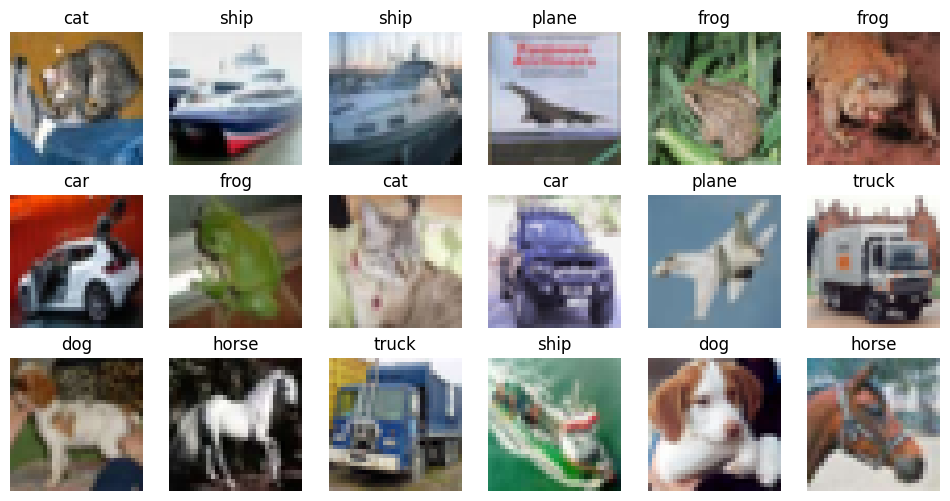

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 3 by 6 grid of images
plt.figure(figsize=(12,6),dpi=100)
for i in range(3):
    for j in range(6):
        plt.subplot(3, 6, 6*i+j+1)
        plt.imshow(testset[6*i+j][0])
        plt.axis('off')
        plt.title(names[testset[6*i+j][1]], fontsize=12)
plt.subplots_adjust(hspace=0.20)
plt.show()

2. We can access the value of the class variables by using the dot notation. For example, print(config.hidden_size) leads to an output of  48 . What is the output for print(config.num_classes)?

In [8]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
class Config: #Define the Config class
    patch_size=4 #Each image patch has a height and width of 4 pixels
    hidden_size=48 #Each image patch is converted to a 48-value tensor
    num_hidden_layers=4
    num_attention_heads=4
    intermediate_size= 4 * 48
    image_size=32
    num_classes=10
    num_channels=3
config=Config() #Instantiates the Config class and names it config

In [10]:
print(config.hidden_size)

48


In [11]:
print(config.num_classes)

10


3. Use torch.randn() to generate a tensor with a size of (5,3,32,32) . Pass the tensor through the PatchEmbeddings class. Print out the shape of the output. What is the meaning of each number in the shape of the output?

In [12]:
from torch import nn

class PatchEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.projection = nn.Conv2d(config.num_channels, #Passes the image through a Conv2d layer
                                    config.hidden_size,
                                    kernel_size=config.patch_size, #Sets the kernel size to 4, which equals the patch size
                                    stride=config.patch_size) #Sets the stride size to 4, which equals the patch size
    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2) #Rearranges the output so it has a dimension of 64 × 48
        return x

In [13]:
patchembed=PatchEmbeddings(config)
img=torch.randn((5,3,32,32)) #aici-------------------------------------------------
out=patchembed(img) # Passes the image through the PatchEmbeddings class
print(out.shape) #Shows the shape of the output

torch.Size([5, 64, 48])
